
# Python Helper Libraries Learning Notebook

This notebook is a practical guide to several very useful Python helper libraries and standard modules:

- **rich**
- **os**
- **shutil**
- **pathlib.Path**
- **json**
- **argparse**
- **requests**
- **Pillow (PIL)**

It focuses on:
- the most used methods and functions
- common real-world workflows
- file handling, paths, copying, JSON data, CLI arguments, HTTP requests, terminal formatting, and image processing

**Note:** some of these are part of the Python standard library (`os`, `shutil`, `pathlib`, `json`, `argparse`), while others are third-party libraries (`rich`, `requests`, `Pillow`).



## 1) Jupyter setup

Install the third-party packages:

```bash
pip install rich requests pillow jupyter
jupyter notebook
```

or with conda:

```bash
conda install jupyter pillow requests
pip install rich
jupyter notebook
```

Standard library modules do not need installation:
- `os`
- `shutil`
- `pathlib`
- `json`
- `argparse`


In [1]:

import os
import shutil
import json
import argparse
from pathlib import Path

import requests
from PIL import Image, ImageDraw, ImageFilter, ImageOps
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.progress import track
from rich.pretty import pprint

console = Console()

print("Imports loaded successfully.")


/opt/homebrew/anaconda3/envs/mlenv/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Imports loaded successfully.


## 2) Create a safe workspace for examples

In [2]:

workspace = Path("helper_libs_demo")
workspace.mkdir(exist_ok=True)

(workspace / "data").mkdir(exist_ok=True)
(workspace / "images").mkdir(exist_ok=True)
(workspace / "copies").mkdir(exist_ok=True)

print("Workspace created at:", workspace.resolve())


Workspace created at: /Users/fiona_spencer/Desk/ML/notebooks/helper_libs_demo


# Part A — pathlib.Path

## 3) Why `pathlib.Path` is useful

In [3]:

base = Path("helper_libs_demo")
data_dir = base / "data"
file_path = data_dir / "example.txt"

print("Base:", base)
print("Data dir:", data_dir)
print("File path:", file_path)
print("Absolute path:", file_path.resolve())


Base: helper_libs_demo
Data dir: helper_libs_demo/data
File path: helper_libs_demo/data/example.txt
Absolute path: /Users/fiona_spencer/Desk/ML/notebooks/helper_libs_demo/data/example.txt


In [4]:

print("Exists?", data_dir.exists())
print("Is dir?", data_dir.is_dir())
print("Parent:", file_path.parent)
print("Name:", file_path.name)
print("Stem:", file_path.stem)
print("Suffix:", file_path.suffix)
print("Parts:", file_path.parts)


Exists? True
Is dir? True
Parent: helper_libs_demo/data
Name: example.txt
Stem: example
Suffix: .txt
Parts: ('helper_libs_demo', 'data', 'example.txt')


In [5]:

file_path.write_text("Hello from pathlib!\nThis file was created with Path.write_text().", encoding="utf-8")
print(file_path.read_text(encoding="utf-8"))


Hello from pathlib!
This file was created with Path.write_text().


In [6]:

# Path methods often used in practice
path_methods = [
    "exists", "is_file", "is_dir", "mkdir", "rmdir", "unlink",
    "write_text", "read_text", "write_bytes", "read_bytes",
    "iterdir", "glob", "rglob", "resolve", "rename", "replace",
    "suffix", "stem", "name", "parent", "parts"
]
print("Common Path features:")
for method in path_methods:
    print("-", method)


Common Path features:
- exists
- is_file
- is_dir
- mkdir
- rmdir
- unlink
- write_text
- read_text
- write_bytes
- read_bytes
- iterdir
- glob
- rglob
- resolve
- rename
- replace
- suffix
- stem
- name
- parent
- parts


## 4) Iterating files with Path

In [7]:

for i in range(3):
    (data_dir / f"sample_{i}.txt").write_text(f"File number {i}", encoding="utf-8")

print("Files in data_dir:")
for p in data_dir.iterdir():
    print("-", p.name)


Files in data_dir:
- example.txt
- sample_2.txt
- sample_1.txt
- sample_0.txt


In [8]:

print("Only .txt files using glob:")
for p in data_dir.glob("*.txt"):
    print("-", p.name)


Only .txt files using glob:
- example.txt
- sample_2.txt
- sample_1.txt
- sample_0.txt


# Part B — os

## 5) Common `os` features

In [9]:

print("Current working directory:")
print(os.getcwd())

print("\nEnvironment variable sample:")
print("HOME =", os.environ.get("HOME"))

print("\nList directory with os.listdir:")
print(os.listdir(workspace))


Current working directory:
/Users/fiona_spencer/Desk/ML/notebooks

Environment variable sample:
HOME = /Users/fiona_spencer

List directory with os.listdir:
['.DS_Store', 'images', 'copies', 'data']


In [10]:

joined = os.path.join("helper_libs_demo", "data", "joined_example.txt")
print("Joined path:", joined)
print("Basename:", os.path.basename(joined))
print("Dirname:", os.path.dirname(joined))
print("Splitext:", os.path.splitext(joined))
print("Exists:", os.path.exists(joined))


Joined path: helper_libs_demo/data/joined_example.txt
Basename: joined_example.txt
Dirname: helper_libs_demo/data
Splitext: ('helper_libs_demo/data/joined_example', '.txt')
Exists: False


In [11]:

os_methods = [
    "getcwd", "chdir", "listdir", "makedirs", "remove", "rename",
    "environ", "walk"
]
os_path_methods = [
    "join", "exists", "isfile", "isdir", "basename", "dirname",
    "splitext", "abspath"
]

print("Common os methods:")
for item in os_methods:
    print("-", item)

print("\nCommon os.path methods:")
for item in os_path_methods:
    print("-", item)


Common os methods:
- getcwd
- chdir
- listdir
- makedirs
- remove
- rename
- environ
- walk

Common os.path methods:
- join
- exists
- isfile
- isdir
- basename
- dirname
- splitext
- abspath


## 6) Walk through folders with `os.walk`

In [12]:

for root, dirs, files in os.walk(workspace):
    print("ROOT:", root)
    print("  DIRS:", dirs)
    print("  FILES:", files)


ROOT: helper_libs_demo
  DIRS: ['images', 'copies', 'data']
  FILES: ['.DS_Store']
ROOT: helper_libs_demo/images
  DIRS: []
  FILES: []
ROOT: helper_libs_demo/copies
  DIRS: []
  FILES: []
ROOT: helper_libs_demo/data
  DIRS: []
  FILES: ['example.txt', 'sample_2.txt', 'sample_1.txt', 'sample_0.txt']


# Part C — shutil

## 7) Copy, move, and archive files with `shutil`

In [13]:

source_file = data_dir / "example.txt"
copied_file = workspace / "copies" / "example_copy.txt"

shutil.copy(source_file, copied_file)

print("Copied file exists?", copied_file.exists())
print("Copied content:")
print(copied_file.read_text(encoding="utf-8"))


Copied file exists? True
Copied content:
Hello from pathlib!
This file was created with Path.write_text().


In [14]:

moved_file = workspace / "copies" / "example_moved.txt"
shutil.move(str(copied_file), str(moved_file))

print("Moved file exists?", moved_file.exists())
print("Old copied file exists?", copied_file.exists())


Moved file exists? True
Old copied file exists? False


In [15]:

archive_base = str(workspace / "backup_archive")
archive_path = shutil.make_archive(archive_base, "zip", root_dir=workspace)

print("Created archive:", archive_path)


Created archive: /Users/fiona_spencer/Desk/ML/notebooks/helper_libs_demo/backup_archive.zip


In [16]:

shutil_methods = [
    "copy", "copy2", "copytree", "move", "rmtree",
    "make_archive", "unpack_archive"
]
print("Common shutil functions:")
for item in shutil_methods:
    print("-", item)


Common shutil functions:
- copy
- copy2
- copytree
- move
- rmtree
- make_archive
- unpack_archive


# Part D — json

## 8) Working with JSON data

In [17]:

user_data = {
    "name": "Fiona",
    "course": "Python helper libraries",
    "skills": ["pathlib", "json", "requests"],
    "active": True,
    "score": 98
}

json_string = json.dumps(user_data, indent=2)
print("JSON string:")
print(json_string)


JSON string:
{
  "name": "Fiona",
  "course": "Python helper libraries",
  "skills": [
    "pathlib",
    "json",
    "requests"
  ],
  "active": true,
  "score": 98
}


In [18]:

parsed = json.loads(json_string)
print("Parsed back to Python:")
print(parsed)
print("Type:", type(parsed))


Parsed back to Python:
{'name': 'Fiona', 'course': 'Python helper libraries', 'skills': ['pathlib', 'json', 'requests'], 'active': True, 'score': 98}
Type: <class 'dict'>


In [19]:

json_file = data_dir / "user_data.json"

with open(json_file, "w", encoding="utf-8") as f:
    json.dump(user_data, f, indent=2)

with open(json_file, "r", encoding="utf-8") as f:
    loaded_json = json.load(f)

print("Loaded from file:")
print(loaded_json)


Loaded from file:
{'name': 'Fiona', 'course': 'Python helper libraries', 'skills': ['pathlib', 'json', 'requests'], 'active': True, 'score': 98}


In [20]:

json_functions = ["dump", "dumps", "load", "loads"]
print("Common json functions:")
for item in json_functions:
    print("-", item)


Common json functions:
- dump
- dumps
- load
- loads


# Part E — argparse

## 9) Build command-line interfaces with `argparse`

In [21]:

# In Jupyter, argparse is best demonstrated with a manual list of arguments.

parser = argparse.ArgumentParser(description="Demo CLI parser")
parser.add_argument("--name", type=str, default="World", help="Name to greet")
parser.add_argument("--count", type=int, default=1, help="How many times")
parser.add_argument("--verbose", action="store_true", help="Enable verbose output")

demo_args = parser.parse_args(["--name", "Fiona", "--count", "2", "--verbose"])
print(demo_args)
print("name:", demo_args.name)
print("count:", demo_args.count)
print("verbose:", demo_args.verbose)


Namespace(name='Fiona', count=2, verbose=True)
name: Fiona
count: 2
verbose: True


In [22]:

# A small CLI script example you could save as cli_demo.py
cli_example = """
import argparse

parser = argparse.ArgumentParser(description="Simple greeting app")
parser.add_argument("--name", type=str, default="World")
parser.add_argument("--times", type=int, default=1)
args = parser.parse_args()

for _ in range(args.times):
    print(f"Hello, {args.name}!")
"""
print(cli_example)



import argparse

parser = argparse.ArgumentParser(description="Simple greeting app")
parser.add_argument("--name", type=str, default="World")
parser.add_argument("--times", type=int, default=1)
args = parser.parse_args()

for _ in range(args.times):
    print(f"Hello, {args.name}!")



In [23]:

argparse_features = [
    "ArgumentParser", "add_argument", "parse_args",
    "type", "default", "help", "action='store_true'",
    "choices", "nargs"
]

print("Common argparse features:")
for item in argparse_features:
    print("-", item)


Common argparse features:
- ArgumentParser
- add_argument
- parse_args
- type
- default
- help
- action='store_true'
- choices
- nargs


# Part F — requests

## 10) Make HTTP requests with `requests`

In [24]:

# This cell shows the typical structure.
# It may fail if internet access is unavailable in your notebook environment.

url = "https://jsonplaceholder.typicode.com/posts/1"

try:
    response = requests.get(url, timeout=10)
    print("Status code:", response.status_code)
    print("Content-Type:", response.headers.get("Content-Type"))
    print("First 200 chars of text:")
    print(response.text[:200])
except Exception as e:
    print("Request failed in this environment:")
    print(e)


Status code: 200
Content-Type: application/json; charset=utf-8
First 200 chars of text:
{
  "userId": 1,
  "id": 1,
  "title": "sunt aut facere repellat provident occaecati excepturi optio reprehenderit",
  "body": "quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nrepr


In [25]:

try:
    response = requests.get("https://jsonplaceholder.typicode.com/users", timeout=10)
    users = response.json()
    print("Type:", type(users))
    print("First user:")
    print(users[0])
except Exception as e:
    print("Could not fetch JSON:", e)


Type: <class 'list'>
First user:
{'id': 1, 'name': 'Leanne Graham', 'username': 'Bret', 'email': 'Sincere@april.biz', 'address': {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}, 'phone': '1-770-736-8031 x56442', 'website': 'hildegard.org', 'company': {'name': 'Romaguera-Crona', 'catchPhrase': 'Multi-layered client-server neural-net', 'bs': 'harness real-time e-markets'}}


In [26]:

request_example = {
    "method": "GET",
    "url": "https://api.example.com/items",
    "params": {"page": 1, "limit": 5},
    "headers": {"Authorization": "Bearer YOUR_TOKEN"}
}
print("Typical request structure:")
print(request_example)


Typical request structure:
{'method': 'GET', 'url': 'https://api.example.com/items', 'params': {'page': 1, 'limit': 5}, 'headers': {'Authorization': 'Bearer YOUR_TOKEN'}}


In [27]:

requests_functions = [
    "get", "post", "put", "patch", "delete", "head",
    "status_code", "text", "json", "headers", "params",
    "timeout", "raise_for_status"
]

print("Common requests features:")
for item in requests_functions:
    print("-", item)


Common requests features:
- get
- post
- put
- patch
- delete
- head
- status_code
- text
- json
- headers
- params
- timeout
- raise_for_status


# Part G — Pillow (PIL)

## 11) Create and open images with Pillow

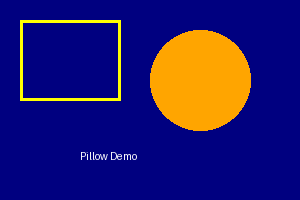

Saved: helper_libs_demo/images/pillow_demo.png


In [28]:

img = Image.new("RGB", (300, 200), color="navy")
draw = ImageDraw.Draw(img)
draw.rectangle((20, 20, 120, 100), outline="yellow", width=3)
draw.ellipse((150, 30, 250, 130), fill="orange")
draw.text((80, 150), "Pillow Demo", fill="white")

img_path = workspace / "images" / "pillow_demo.png"
img.save(img_path)

display(img)
print("Saved:", img_path)


Size: (300, 200)
Mode: RGB


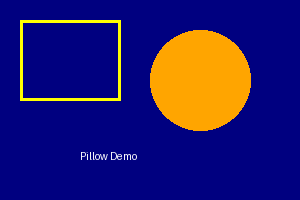

In [29]:

opened = Image.open(img_path)
print("Size:", opened.size)
print("Mode:", opened.mode)
display(opened)


## 12) Resize, crop, rotate, transpose

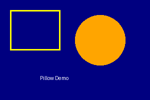

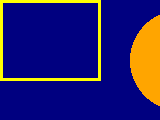

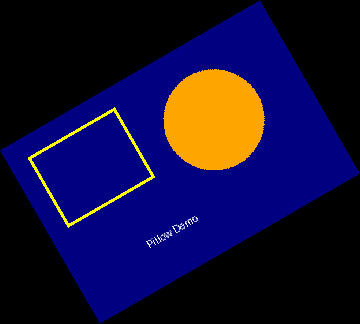

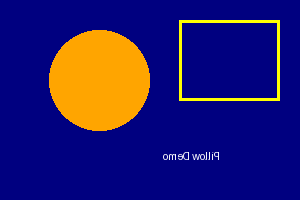

In [30]:

resized = opened.resize((150, 100))
cropped = opened.crop((20, 20, 180, 140))
rotated = opened.rotate(30, expand=True)
flipped = opened.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

display(resized)
display(cropped)
display(rotated)
display(flipped)


In [31]:

pillow_methods = [
    "open", "new", "save", "resize", "crop", "rotate",
    "transpose", "convert", "filter"
]
print("Common Pillow methods:")
for item in pillow_methods:
    print("-", item)


Common Pillow methods:
- open
- new
- save
- resize
- crop
- rotate
- transpose
- convert
- filter


## 13) Filters and image ops

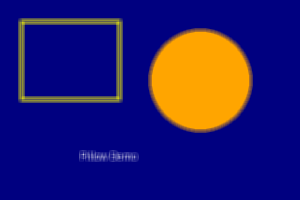

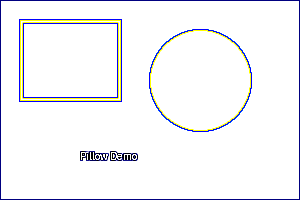

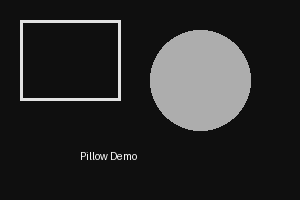

In [32]:

blurred = opened.filter(ImageFilter.BLUR)
contoured = opened.filter(ImageFilter.CONTOUR)
grayscale = ImageOps.grayscale(opened)

display(blurred)
display(contoured)
display(grayscale)


# Part H — rich

## 14) Rich console output

In [33]:

console.print("[bold green]Hello from Rich![/bold green]")
console.print(Panel("This is a Rich panel", title="Rich Demo"))


Hello from Rich!

╭─────────────────────────────────────────────────── Rich Demo ───────────────────────────────────────────────────╮
│ This is a Rich panel                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [34]:

table = Table(title="Students")
table.add_column("Name")
table.add_column("Course")
table.add_column("Score", justify="right")

table.add_row("Fiona", "Python", "95")
table.add_row("Alex", "Data Science", "92")
table.add_row("Sam", "ML", "89")

console.print(table)


            Students            
┏━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Name  ┃ Course       ┃ Score ┃
┡━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━┩
│ Fiona │ Python       │    95 │
│ Alex  │ Data Science │    92 │
│ Sam   │ ML           │    89 │
└───────┴──────────────┴───────┘

In [35]:

sample_dict = {
    "library": "rich",
    "features": ["console", "table", "panel", "progress", "pretty"],
    "useful": True
}
pprint(sample_dict)


{'library': 'rich', 'features': ['console', 'table', 'panel', 'progress', 'pretty'], 'useful': True}

In [39]:

for i in track(range(1000), description="Working..."):
    pass
print("Progress demo finished.")


Output()

Progress demo finished.


In [40]:

rich_features = [
    "Console", "print", "Table", "Panel", "Progress",
    "track", "pprint", "Markdown", "Syntax"
]

print("Common Rich features:")
for item in rich_features:
    print("-", item)


Common Rich features:
- Console
- print
- Table
- Panel
- Progress
- track
- pprint
- Markdown
- Syntax


# Part I — Combined mini workflows

## 15) Combined example: Path + json + shutil

In [41]:

report = {
    "project": "helper libraries demo",
    "files_created": [p.name for p in data_dir.glob("*")],
    "image_files": [p.name for p in (workspace / "images").glob("*")]
}

report_path = workspace / "data" / "report.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

backup_report = workspace / "copies" / "report_backup.json"
shutil.copy(report_path, backup_report)

print("Report saved to:", report_path)
print("Backup saved to:", backup_report)
print(report_path.read_text(encoding="utf-8"))


Report saved to: helper_libs_demo/data/report.json
Backup saved to: helper_libs_demo/copies/report_backup.json
{
  "project": "helper libraries demo",
  "files_created": [
    "user_data.json",
    "example.txt",
    "sample_2.txt",
    "sample_1.txt",
    "sample_0.txt"
  ],
  "image_files": [
    "pillow_demo.png"
  ]
}


## 16) Combined example: requests + json

In [42]:

try:
    r = requests.get("https://jsonplaceholder.typicode.com/todos/1", timeout=10)
    r.raise_for_status()
    todo = r.json()

    todo_file = workspace / "data" / "todo.json"
    todo_file.write_text(json.dumps(todo, indent=2), encoding="utf-8")

    print("Downloaded JSON and saved to:", todo_file)
    print(todo)
except Exception as e:
    print("Could not run live HTTP example:")
    print(e)


Downloaded JSON and saved to: helper_libs_demo/data/todo.json
{'userId': 1, 'id': 1, 'title': 'delectus aut autem', 'completed': False}


## 17) Combined example: Pillow + Path

Thumbnail saved to: helper_libs_demo/images/thumbnail.png


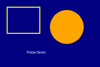

In [43]:

thumb_path = workspace / "images" / "thumbnail.png"
thumbnail = opened.copy()
thumbnail.thumbnail((100, 100))
thumbnail.save(thumb_path)

print("Thumbnail saved to:", thumb_path)
display(thumbnail)


# Part J — Quick reference

In [44]:

reference = {
    "pathlib.Path": ["Path", "exists", "mkdir", "glob", "iterdir", "read_text", "write_text", "rename", "unlink"],
    "os": ["getcwd", "listdir", "walk", "environ", "path.join", "path.exists"],
    "shutil": ["copy", "copy2", "move", "copytree", "rmtree", "make_archive"],
    "json": ["dump", "dumps", "load", "loads"],
    "argparse": ["ArgumentParser", "add_argument", "parse_args"],
    "requests": ["get", "post", "json", "text", "headers", "status_code", "raise_for_status"],
    "Pillow": ["Image.open", "Image.new", "save", "resize", "crop", "rotate", "filter"],
    "rich": ["Console.print", "Table", "Panel", "track", "pprint"],
}

for lib, items in reference.items():
    print(f"\n{lib}:")
    print(", ".join(items))



pathlib.Path:
Path, exists, mkdir, glob, iterdir, read_text, write_text, rename, unlink

os:
getcwd, listdir, walk, environ, path.join, path.exists

shutil:
copy, copy2, move, copytree, rmtree, make_archive

json:
dump, dumps, load, loads

argparse:
ArgumentParser, add_argument, parse_args

requests:
get, post, json, text, headers, status_code, raise_for_status

Pillow:
Image.open, Image.new, save, resize, crop, rotate, filter

rich:
Console.print, Table, Panel, track, pprint


## 18) Inspect public names

In [45]:

print("Some public names in os:")
print([name for name in dir(os) if not name.startswith("_")][:80])

print("\nSome public names in shutil:")
print([name for name in dir(shutil) if not name.startswith("_")][:80])

print("\nSome public names in json:")
print([name for name in dir(json) if not name.startswith("_")][:80])

print("\nSome public names in requests:")
print([name for name in dir(requests) if not name.startswith("_")][:80])


Some public names in os:
['CLD_CONTINUED', 'CLD_DUMPED', 'CLD_EXITED', 'CLD_KILLED', 'CLD_STOPPED', 'CLD_TRAPPED', 'DirEntry', 'EX_CANTCREAT', 'EX_CONFIG', 'EX_DATAERR', 'EX_IOERR', 'EX_NOHOST', 'EX_NOINPUT', 'EX_NOPERM', 'EX_NOUSER', 'EX_OK', 'EX_OSERR', 'EX_OSFILE', 'EX_PROTOCOL', 'EX_SOFTWARE', 'EX_TEMPFAIL', 'EX_UNAVAILABLE', 'EX_USAGE', 'F_LOCK', 'F_OK', 'F_TEST', 'F_TLOCK', 'F_ULOCK', 'GenericAlias', 'Mapping', 'MutableMapping', 'NGROUPS_MAX', 'O_ACCMODE', 'O_APPEND', 'O_ASYNC', 'O_CLOEXEC', 'O_CREAT', 'O_DIRECTORY', 'O_DSYNC', 'O_EVTONLY', 'O_EXCL', 'O_EXLOCK', 'O_FSYNC', 'O_NDELAY', 'O_NOCTTY', 'O_NOFOLLOW', 'O_NOFOLLOW_ANY', 'O_NONBLOCK', 'O_RDONLY', 'O_RDWR', 'O_SHLOCK', 'O_SYMLINK', 'O_SYNC', 'O_TRUNC', 'O_WRONLY', 'POSIX_SPAWN_CLOSE', 'POSIX_SPAWN_DUP2', 'POSIX_SPAWN_OPEN', 'PRIO_PGRP', 'PRIO_PROCESS', 'PRIO_USER', 'P_ALL', 'P_NOWAIT', 'P_NOWAITO', 'P_PGID', 'P_PID', 'P_WAIT', 'PathLike', 'RTLD_GLOBAL', 'RTLD_LAZY', 'RTLD_LOCAL', 'RTLD_NODELETE', 'RTLD_NOLOAD', 'RTLD_NOW', 


## 19) Practice exercises

1. Create a new folder with `Path.mkdir()`.
2. Save a text file with `write_text()` and read it back.
3. Use `os.walk()` to list all files in a folder tree.
4. Copy a file with `shutil.copy()` and move it with `shutil.move()`.
5. Convert a Python dictionary to JSON with `json.dumps()`.
6. Build a simple CLI parser with `argparse`.
7. Make a GET request with `requests.get()` and parse JSON.
8. Create an image with Pillow and save it.
9. Print a styled table with Rich.



## 20) Summary

You now have a notebook covering several very useful Python helper libraries:

- **pathlib.Path** for modern path handling
- **os** for operating system utilities
- **shutil** for file copying, moving, and archiving
- **json** for structured data
- **argparse** for CLI apps
- **requests** for HTTP APIs
- **Pillow** for image creation and editing
- **rich** for beautiful terminal output

Together, these libraries are extremely useful for scripting, automation, apps, ML projects, and data workflows.
